# Bias Detection & Fairness Analysis

This notebook implements bias detection and fairness analysis for the NovaCred credit application dataset.
As part of the Data Governance Task Force, the goal is to identify potential discrimination in historical
lending decisions and quantify bias using established fairness metrics.

**Analyses performed:**
1. Gender Bias — Disparate Impact Ratio (four-fifths rule)
2. Statistical Significance Testing — Chi-squared test
3. Fairlearn Fairness Metrics — Demographic parity difference
4. Rejection Reason Analysis — Gender-based rejection patterns
5. Proxy Discrimination — Spending categories and income as gender proxies
6. Intersectional Analysis — Approval patterns across income brackets and gender

## 1. Setup & Data Loading

We load the consolidated dataset produced by the Data Engineering pipeline. This dataset
merges the original application data with pivoted spending behavior into a single file.

In [1]:
# Import libraries for data analysis, visualization, statistical testing, and fairness metrics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    MetricFrame,
    selection_rate
)

# Configure plotting style for consistent visuals
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Suppress non-critical warnings for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


### Quick Dataset inspection

In [2]:
# Load the cleaned dataset produced by the data remediation pipeline
df = pd.read_csv('../data/processed/cleaned_credit_applications.csv')

# Print basic dataset dimensions (rows x columns)
print(f'Dataset shape: {df.shape[0]} records x {df.shape[1]} columns')

# Display all column names to understand available features
print(f'\nColumns:')
for i, col in enumerate(df.columns):
    print(f'  {i+1:2d}. {col}')

# Check distribution of the sensitive attribute (gender)
print(f'\nGender distribution:')
print(df['applicant_info.gender'].value_counts(dropna=False))

# Compute overall loan approval rate
print(f'\nOverall approval rate: {df["decision.loan_approved"].mean():.1%}')

Dataset shape: 500 records x 35 columns

Columns:
   1. _id
   2. processing_timestamp
   3. applicant_info.full_name
   4. applicant_info.email
   5. applicant_info.ssn
   6. applicant_info.ip_address
   7. applicant_info.gender
   8. applicant_info.date_of_birth
   9. applicant_info.zip_code
  10. financials.annual_income
  11. financials.credit_history_months
  12. financials.debt_to_income
  13. financials.savings_balance
  14. decision.loan_approved
  15. decision.rejection_reason
  16. loan_purpose
  17. decision.interest_rate
  18. decision.approved_amount
  19. notes
  20. spending_Adult_Entertainment
  21. spending_Alcohol
  22. spending_Dining
  23. spending_Education
  24. spending_Entertainment
  25. spending_Fitness
  26. spending_Gambling
  27. spending_Groceries
  28. spending_Healthcare
  29. spending_Insurance
  30. spending_Rent
  31. spending_Shopping
  32. spending_Transportation
  33. spending_Travel
  34. spending_Utilities
  35. flag_duplicate_ssn

Gender distrib

In [3]:
# Filter dataset to only Male and Female applicants for binary fairness analysis
# Records with 'Unknown' gender are excluded to allow comparison between two groups

df_bias = df[df['applicant_info.gender'].isin(['Male', 'Female'])].copy()

# Create binary gender variable (Male = 1, Female = 0), if true bool -> 1 (reference), false bool -> 0 protected group
df_bias['gender_binary'] = (df_bias['applicant_info.gender'] == 'Male').astype(int)

# Convert loan approval from boolean to numeric (Approved = 1, Rejected = 0)
df_bias['approved_binary'] = df_bias['decision.loan_approved'].astype(int)

# Print summary of records used in the bias analysis
print(f'Records for bias analysis: {len(df_bias)} (excluded {len(df) - len(df_bias)} with Unknown gender)')
print(f'Female: {len(df_bias[df_bias["applicant_info.gender"]=="Female"])}')
print(f'Male:   {len(df_bias[df_bias["applicant_info.gender"]=="Male"])}')

Records for bias analysis: 498 (excluded 2 with Unknown gender)
Female: 251
Male:   247


For the binary fairness analysis, Female applicants are treated as the protected group and Male applicants as the reference group.

---
## 2. Disparate Impact Ratio (DIR) — Four-Fifths Rule

The **Disparate Impact Ratio** measures whether a selection process disproportionately affects a protected group.
Under the EEOC's **four-fifths (80%) rule**, a selection rate for any group less than 80% of the highest-performing
group constitutes evidence of adverse impact.

$$DIR = \frac{\text{Approval Rate}_{\text{unprivileged}}}{\text{Approval Rate}_{\text{privileged}}}$$

- **DIR < 0.8** → Potential disparate impact (violates four-fifths rule)
- **DIR = 1.0** → Perfect parity

In [4]:
# Calculate loan approval statistics by gender
approval_rates = df_bias.groupby('applicant_info.gender')['decision.loan_approved'].agg(['mean', 'sum', 'count'])

# Rename columns to make them easier to interpret
approval_rates.columns = ['Approval Rate', 'Approved Count', 'Total Count']

# Calculate number of rejected applications
approval_rates['Rejected Count'] = approval_rates['Total Count'] - approval_rates['Approved Count']

print('=== Approval Statistics by Gender ===')
print(approval_rates.to_string())

# Compute Disparate Impact Ratio (DIR)
rate_female = approval_rates.loc['Female', 'Approval Rate']
rate_male = approval_rates.loc['Male', 'Approval Rate']
DIR = rate_female / rate_male

# Display fairness evaluation results
print(f'\n{"="*50}')
print(f'Female Approval Rate: {rate_female:.1%} ({int(approval_rates.loc["Female","Approved Count"])}/{int(approval_rates.loc["Female","Total Count"])})')
print(f'Male Approval Rate:   {rate_male:.1%} ({int(approval_rates.loc["Male","Approved Count"])}/{int(approval_rates.loc["Male","Total Count"])})')

print(f'\nDisparate Impact Ratio (DIR): {DIR:.4f}')
print(f'Four-Fifths Threshold:         0.8000')

# Apply the Four-Fifths Rule to determine whether disparate impact exists
print(f'\nVERDICT: {"DISPARATE IMPACT DETECTED" if DIR < 0.8 else "No disparate impact"}')

print(f'The female approval rate is {DIR:.1%} of the male rate, which is')
print(f'{"BELOW" if DIR < 0.8 else "above"} the 80% threshold.')

=== Approval Statistics by Gender ===
                       Approval Rate  Approved Count  Total Count  Rejected Count
applicant_info.gender                                                            
Female                      0.505976             127          251             124
Male                        0.659919             163          247              84

Female Approval Rate: 50.6% (127/251)
Male Approval Rate:   66.0% (163/247)

Disparate Impact Ratio (DIR): 0.7667
Four-Fifths Threshold:         0.8000

VERDICT: DISPARATE IMPACT DETECTED
The female approval rate is 76.7% of the male rate, which is
BELOW the 80% threshold.


The approval rate for female applicants is only 76.7% of the male rate, which falls below the 80% Four-Fifths threshold and therefore **indicates potential disparate impact** that should be investigated. <br>
<br>
**The Four-Fifths Rule does not prove discrimination**, it only flags a potential bias that requires further analysis (e.g., statistical testing or checking confounding variables like income, credit history, etc.).

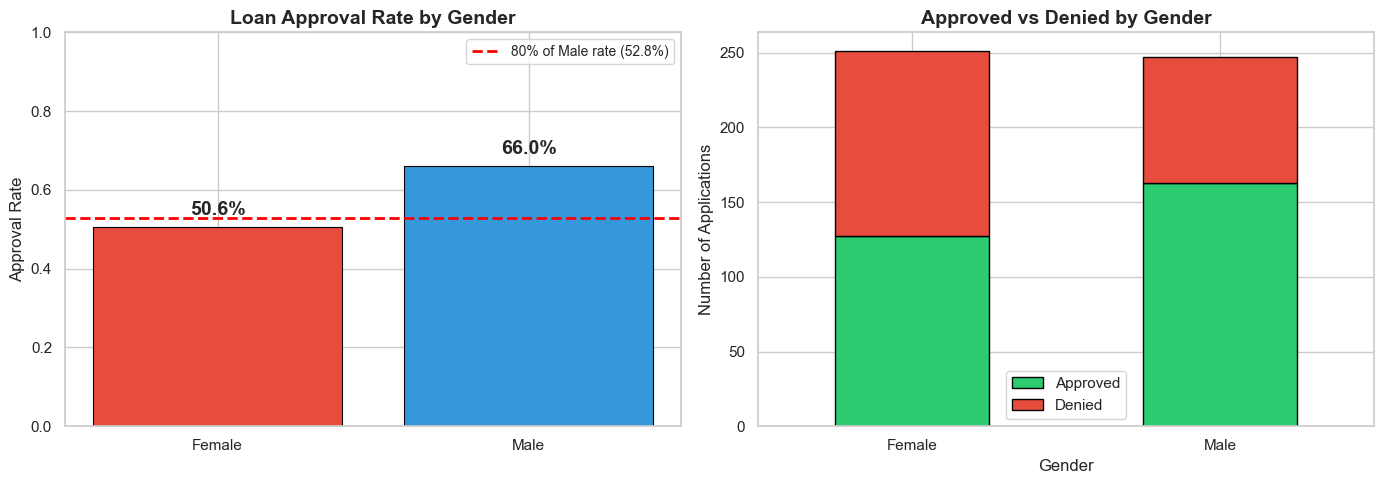


Disparate Impact Ratio = 0.7667 (threshold: 0.8)


In [5]:
# Visualize approval rates with DIR threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of approval rates
colors = ['#e74c3c', '#3498db']
bars = axes[0].bar(['Female', 'Male'], [rate_female, rate_male], color=colors, edgecolor='black', linewidth=0.8)
axes[0].axhline(y=rate_male * 0.8, color='red', linestyle='--', linewidth=2, label=f'80% of Male rate ({rate_male*0.8:.1%})')
axes[0].set_ylabel('Approval Rate', fontsize=12)
axes[0].set_title('Loan Approval Rate by Gender', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=10)
for bar, rate in zip(bars, [rate_female, rate_male]):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{rate:.1%}', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Stacked bar chart: approved vs denied
approval_data = approval_rates[['Approved Count', 'Rejected Count']]
approval_data.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Approved vs Denied by Gender', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Applications')
axes[1].set_xlabel('Gender')
axes[1].legend(['Approved', 'Denied'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/gender_approval_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nDisparate Impact Ratio = {DIR:.4f} (threshold: 0.8)')

---
## 3. Statistical Significance Testing

We perform a **Chi-squared test of independence** to determine whether the relationship between
gender and loan approval is statistically significant (not due to chance).

- **H₀ (Null):** Gender and loan approval are independent
- **H₁ (Alternative):** Gender and loan approval are associated
- **Significance level:** α = 0.05

In [6]:
# Build a contingency table (gender x approval outcome) to support a chi-square test
contingency = pd.crosstab(
    df_bias['applicant_info.gender'],
    df_bias['decision.loan_approved'],
    margins=True
)
contingency.columns = ['Rejected', 'Approved', 'Total']
contingency.index = ['Female', 'Male', 'Total']

print('=== Contingency Table ===')
print(contingency)

# Run Chi-Squared Test of Independence: checks whether approval outcome depends on gender
ct = pd.crosstab(df_bias['applicant_info.gender'], df_bias['decision.loan_approved'])
chi2, p_value, dof, expected = stats.chi2_contingency(ct)

print(f'\n=== Chi-Squared Test of Independence ===')
print(f'Chi² statistic:     {chi2:.4f}')
print(f'p-value:            {p_value:.6f}')
print(f'Degrees of freedom: {dof}')

# Display expected counts under the assumption of independence (no association)
expected_df = pd.DataFrame(expected, index=['Female', 'Male'], columns=['Rejected', 'Approved'])
print(f'\nExpected frequencies (if independent):')
print(expected_df.round(1))

print(f'\n{"="*50}')
print(f'RESULT: The association is {"STATISTICALLY SIGNIFICANT" if p_value < 0.05 else "not significant"} (p = {p_value:.6f})')
if p_value < 0.05:
    print(f'We reject H₀: gender and loan approval are NOT independent.')

# Quantify strength of association using Cramér's V (effect size)
n = len(df_bias)
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
effect = (
    'negligible' if cramers_v < 0.1 else
    'small-to-moderate' if cramers_v < 0.3 else
    'moderate' if cramers_v < 0.5 else
    'large'
)
print(f'\nEffect Size (Cramér\'s V): {cramers_v:.4f} ({effect})')

=== Contingency Table ===
        Rejected  Approved  Total
Female       124       127    251
Male          84       163    247
Total        208       290    498

=== Chi-Squared Test of Independence ===
Chi² statistic:     11.5053
p-value:            0.000694
Degrees of freedom: 1

Expected frequencies (if independent):
        Rejected  Approved
Female     104.8     146.2
Male       103.2     143.8

RESULT: The association is STATISTICALLY SIGNIFICANT (p = 0.000694)
We reject H₀: gender and loan approval are NOT independent.

Effect Size (Cramér's V): 0.1520 (small-to-moderate)


**The chi-squared test indicates a statistically significant relationship between gender and loan approval (χ² = 11.51, p = 0.000694)**, meaning approval decisions are not independent of gender. Combined with the Disparate Impact Ratio below the 0.8 threshold, this suggests that female applicants are approved at a significantly lower rate than male applicants. However, **the effect size (Cramér’s V = 0.15) indicates the magnitude of this association is small-to-moderate**.

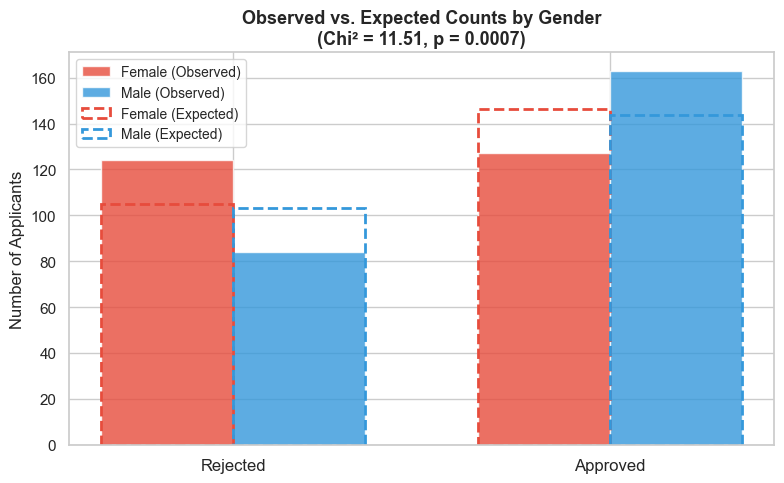

In [7]:
# Visualize observed vs expected counts from the chi-square test
fig, ax = plt.subplots(figsize=(8, 5))

# Positions for the bars (Rejected, Approved)
x = np.arange(2)
width = 0.35

# Observed counts from the contingency table
observed_female = [ct.loc['Female', False], ct.loc['Female', True]]
observed_male = [ct.loc['Male', False], ct.loc['Male', True]]

# Plot observed values as filled bars
bars1 = ax.bar(x - width/2, observed_female, width, label='Female (Observed)', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, observed_male, width, label='Male (Observed)', color='#3498db', alpha=0.8)

# Plot expected counts (under independence assumption) as dashed outlines
ax.bar(x - width/2,
       [expected_df.loc['Female', 'Rejected'], expected_df.loc['Female', 'Approved']],
       width, label='Female (Expected)', fill=False, edgecolor='#e74c3c', linewidth=2, linestyle='--')

ax.bar(x + width/2,
       [expected_df.loc['Male', 'Rejected'], expected_df.loc['Male', 'Approved']],
       width, label='Male (Expected)', fill=False, edgecolor='#3498db', linewidth=2, linestyle='--')

# Axis labels and title
ax.set_xticks(x)
ax.set_xticklabels(['Rejected', 'Approved'], fontsize=12)
ax.set_ylabel('Number of Applicants', fontsize=12)
ax.set_title(f'Observed vs. Expected Counts by Gender\n(Chi² = {chi2:.2f}, p = {p_value:.4f})', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Adjust layout, save figure for report, and display it
plt.tight_layout()
plt.savefig('../reports/chi_squared_test.png', dpi=150, bbox_inches='tight')
plt.show()

The figure shows that **female applicants receive fewer approvals and more rejections than expected** under the assumption of gender-independent decision making, **while male applicants receive more approvals than expected.** This pattern is consistent with the statistically significant chi-square test and indicates a gender-related disparity in loan approval outcomes.

---
## 4. Fairlearn Fairness Metrics

Using Microsoft's [Fairlearn](https://fairlearn.org/) library, we compute standardized fairness metrics:

- **Demographic Parity Difference (DPD):** Difference in selection rates between groups. Ideal = 0.
- **Demographic Parity Ratio (DPR):** Ratio of selection rates. Ideal = 1. (Equivalent to DIR.)

In [8]:
# Prepare arrays for Fairlearn metrics
y_true = df_bias['approved_binary'].values
sensitive = df_bias['applicant_info.gender'].values

# Here, the observed loan decision is treated as the "model prediction"
# (we are auditing outcomes, not training a new model)
y_pred = y_true

# Fairness metrics: demographic parity (difference + ratio)
dpd = demographic_parity_difference(y_true=y_true, y_pred=y_pred, sensitive_features=sensitive)
dpr = demographic_parity_ratio(y_true=y_true, y_pred=y_pred, sensitive_features=sensitive)

print('=== Fairlearn Fairness Metrics ===')
print(f'Demographic Parity Difference (DPD): {dpd:.4f}')
print(f'  Ideal = 0 | Observed gap = {abs(dpd):.1%} difference in approval rates')
print(f'  {"UNFAIR" if abs(dpd) > 0.1 else "Within acceptable range"} (threshold: |DPD| > 0.10)\n')

print(f'Demographic Parity Ratio (DPR):      {dpr:.4f}')
print(f'  Ideal = 1.0 | Matches DIR calculation: {DIR:.4f}')
print(f'  {"UNFAIR" if dpr < 0.8 else "Within acceptable range"} (four-fifths rule: DPR < 0.80)')

# Per-group breakdown (approval rate/selection rate + group size)
mf = MetricFrame(
    metrics={'selection_rate': selection_rate, 'count': lambda y_true, y_pred: len(y_true)},
    y_true=y_true, y_pred=y_true, sensitive_features=sensitive
)
print(f'\nPer-group metrics:')
print(mf.by_group)
print(f'\nOverall selection rate: {mf.overall["selection_rate"]:.4f}')

=== Fairlearn Fairness Metrics ===
Demographic Parity Difference (DPD): 0.1539
  Ideal = 0 | Observed gap = 15.4% difference in approval rates
  UNFAIR (threshold: |DPD| > 0.10)

Demographic Parity Ratio (DPR):      0.7667
  Ideal = 1.0 | Matches DIR calculation: 0.7667
  UNFAIR (four-fifths rule: DPR < 0.80)

Per-group metrics:
                     selection_rate  count
sensitive_feature_0                       
Female                     0.505976  251.0
Male                       0.659919  247.0

Overall selection rate: 0.5823


The combined results from the Disparate Impact Ratio, chi-square test, and Fairlearn demographic parity metrics consistently reveal a statistically significant gender disparity in loan approval decisions, indicating that female applicants are approved at a lower rate than male applicants and suggesting the presence of potential algorithmic bias that warrants further investigation.

---
## 5. Rejection Reason Analysis

Examining the distribution of rejection reasons by gender to understand where the algorithm
disproportionately rejects female applicants.

In [18]:
# Filter dataset to only rejected loan applications
rejected = df_bias[df_bias['decision.loan_approved'] == False].copy()

# Create a contingency table showing rejection reasons by gender
rejection_ct = pd.crosstab(
    rejected['applicant_info.gender'],
    rejected['decision.rejection_reason'],
    margins=True
)

print('=== Rejection Reasons by Gender (Counts) ===')
print(rejection_ct)

# Calculate rejection reason proportions within each gender group
print('\n=== Rejection Reason Proportions (within each gender) ===')
rejection_props = pd.crosstab(
    rejected['applicant_info.gender'],
    rejected['decision.rejection_reason'],
    normalize='index'
)

print(rejection_props.round(3))

=== Rejection Reasons by Gender (Counts) ===
decision.rejection_reason  algorithm_risk_score  high_dti_ratio  \
applicant_info.gender                                             
Female                                      100               8   
Male                                         69               4   
All                                         169              12   

decision.rejection_reason  insufficient_credit_history  low_income  All  
applicant_info.gender                                                    
Female                                              15           1  124  
Male                                                 8           3   84  
All                                                 23           4  208  

=== Rejection Reason Proportions (within each gender) ===
decision.rejection_reason  algorithm_risk_score  high_dti_ratio  \
applicant_info.gender                                             
Female                                    0.806         

The analysis of rejection reasons shows that **the majority of loan denials for both genders are driven by the algorithm_risk_score, accounting for approximately 80.6% of female rejections and 82.1% of male rejections.** <br>
 Other rejection reasons such as high debt-to-income ratio and insufficient credit history occur less frequently and at similar proportions across genders. Overall, the distribution of rejection reasons appears broadly similar between male and female applicants, suggesting that the observed approval disparity is likely driven primarily by the algorithmic risk scoring component rather than by individual rule-based rejection criteria.

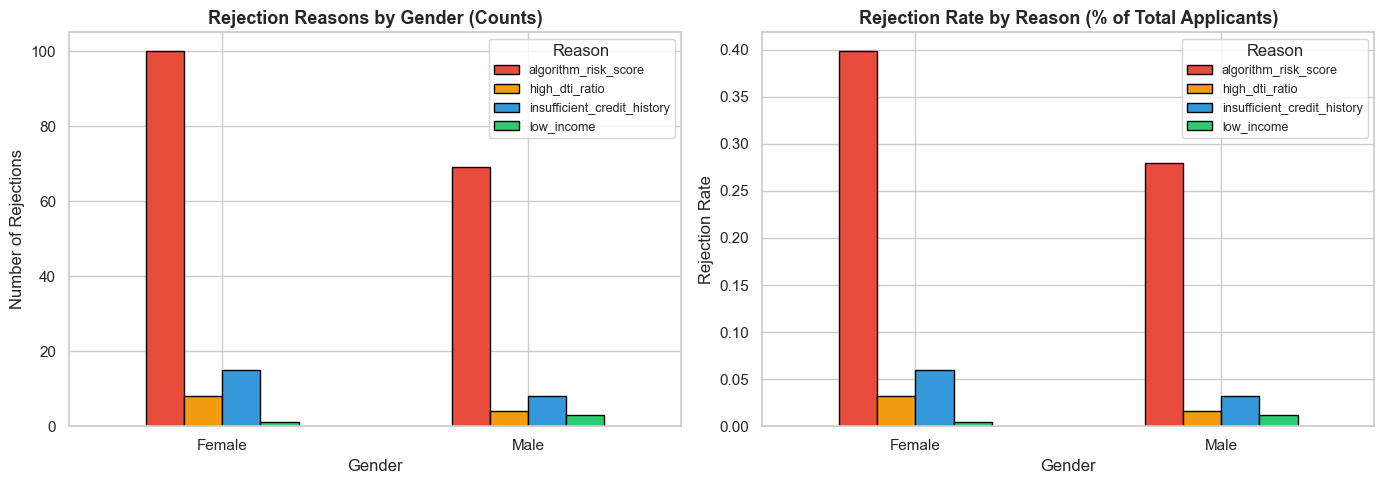

Key Finding: "algorithm_risk_score" rejected 100 females (39.8%) vs 69 males (27.9%)


In [19]:
# Visualize rejection reasons in two ways: raw counts and rejection rates (per applicant)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Absolute rejection counts by gender ---
rejection_counts = pd.crosstab(
    rejected['applicant_info.gender'],
    rejected['decision.rejection_reason']
)
rejection_counts.plot(
    kind='bar', ax=axes[0],
    color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'],
    edgecolor='black'
)
axes[0].set_title('Rejection Reasons by Gender (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Rejections')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Reason', fontsize=9)

# --- Plot 2: Rejection rate by reason (as % of all applicants in each gender) ---
reasons = rejected.groupby(['applicant_info.gender', 'decision.rejection_reason']).size().unstack(fill_value=0)
totals = df_bias.groupby('applicant_info.gender').size()
rejection_rate_by_reason = reasons.div(totals, axis=0)

rejection_rate_by_reason.plot(
    kind='bar', ax=axes[1],
    color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'],
    edgecolor='black'
)
axes[1].set_title('Rejection Rate by Reason (% of Total Applicants)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Rejection Rate')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Reason', fontsize=9)

# Save and display
plt.tight_layout()
plt.savefig('../reports/rejection_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

# Print a short numeric takeaway for the main driver (algorithm_risk_score)
algo_f = rejection_counts.loc['Female', 'algorithm_risk_score'] if 'algorithm_risk_score' in rejection_counts.columns else 0
algo_m = rejection_counts.loc['Male', 'algorithm_risk_score'] if 'algorithm_risk_score' in rejection_counts.columns else 0
total_f = len(df_bias[df_bias['applicant_info.gender'] == 'Female'])
total_m = len(df_bias[df_bias['applicant_info.gender'] == 'Male'])

print(
    f'Key Finding: "algorithm_risk_score" rejected {algo_f} females ({algo_f/total_f:.1%}) '
    f'vs {algo_m} males ({algo_m/total_m:.1%})'
)

---
## 6. Proxy Discrimination Analysis

**Proxy discrimination** occurs when non-protected attributes are correlated with a protected
characteristic (gender) and are used in decision-making, effectively encoding the protected
attribute indirectly.

We investigate:
1. Which features correlate with **both** gender and approval
2. Whether spending patterns differ systematically by gender
3. Whether approval rates differ within comparable financial profiles

In [26]:
# Identify spending and financial features for proxy discrimination analysis
spending_cols = [c for c in df_bias.columns if c.startswith('spending_')]

financial_cols = [
    'financials.annual_income',
    'financials.credit_history_months',
    'financials.debt_to_income',
    'financials.savings_balance'
]

# Combine all features we want to analyze
analysis_cols = financial_cols + spending_cols

correlations = []

# Calculate correlation of each feature with gender and with loan approval
for col in analysis_cols:
    corr_gender = df_bias[['gender_binary', col]].corr().iloc[0, 1]
    corr_approval = df_bias[['approved_binary', col]].corr().iloc[0, 1]

    correlations.append({
        'Feature': col.replace('spending_', 'Spending: ').replace('financials.', ''),
        'Corr with Gender (Male=1)': round(corr_gender, 4),
        'Corr with Approval': round(corr_approval, 4),

        # Flag potential proxy variables
        'Proxy Risk': 'HIGH'
        if abs(corr_gender) > 0.05 and abs(corr_approval) > 0.05
        else 'MODERATE'
        if abs(corr_gender) > 0.05 or abs(corr_approval) > 0.05
        else 'LOW'
    })

# Create results table and display
corr_df = pd.DataFrame(correlations).sort_values('Proxy Risk', ascending=True)

print('=== Feature Correlation Analysis ===')
print(corr_df.to_string(index=False))

=== Feature Correlation Analysis ===
                      Feature  Corr with Gender (Male=1)  Corr with Approval Proxy Risk
           Spending: Shopping                     0.0856              0.0753       HIGH
          Spending: Insurance                     0.0518              0.0731       HIGH
            Spending: Fitness                     0.0318             -0.0353        LOW
     Spending: Transportation                     0.0313              0.0127        LOW
         Spending: Healthcare                    -0.0286              0.0016        LOW
             Spending: Travel                     0.0098             -0.0197        LOW
      Spending: Entertainment                    -0.0488             -0.0384        LOW
          Spending: Utilities                    -0.0045              0.0329        LOW
               debt_to_income                     0.0163              0.0168        LOW
             Spending: Dining                     0.0245             -0.0611   MODE

Correlations with gender are computed using a binary encoding (Male = 1, Female = 0), meaning positive values indicate higher feature values among male applicants, while negative values indicate higher values among female applicants.

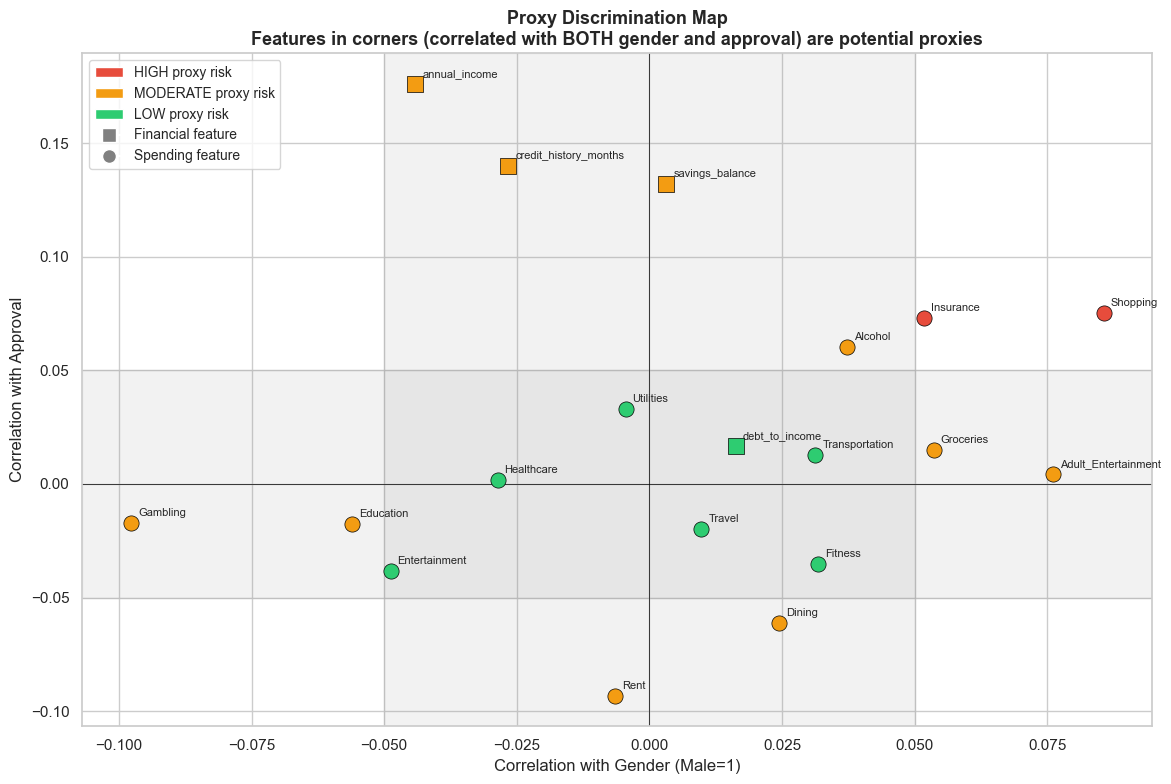

In [27]:
# Scatter plot of each feature: correlation with gender (x-axis) vs correlation with approval (y-axis)
fig, ax = plt.subplots(figsize=(12, 8))

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Plot each feature as a point, colored by proxy risk and shaped by feature type (spending vs financial)
for _, row in corr_df.iterrows():
    color = {'HIGH': '#e74c3c', 'MODERATE': '#f39c12', 'LOW': '#2ecc71'}[row['Proxy Risk']]
    marker = 's' if not row['Feature'].startswith('Spending') else 'o'

    ax.scatter(
        row['Corr with Gender (Male=1)'], row['Corr with Approval'],
        c=color, s=120, marker=marker, edgecolors='black', linewidth=0.5, zorder=5
    )

    ax.annotate(
        row['Feature'].replace('Spending: ', ''),
        (row['Corr with Gender (Male=1)'], row['Corr with Approval']),
        textcoords='offset points', xytext=(5, 5), fontsize=8
    )

# Highlight the "near-zero correlation" zone using ±0.05 bands
ax.axhspan(-0.05, 0.05, color='gray', alpha=0.1)
ax.axvspan(-0.05, 0.05, color='gray', alpha=0.1)

# Add reference lines at zero
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)

# Custom legend: colors show proxy risk, marker shapes show feature type
legend_elements = [
    Patch(facecolor='#e74c3c', label='HIGH proxy risk'),
    Patch(facecolor='#f39c12', label='MODERATE proxy risk'),
    Patch(facecolor='#2ecc71', label='LOW proxy risk'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Financial feature'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Spending feature'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

# Axis labels and plot title
ax.set_xlabel('Correlation with Gender (Male=1)', fontsize=12)
ax.set_ylabel('Correlation with Approval', fontsize=12)
ax.set_title(
    'Proxy Discrimination Map\nFeatures in corners (correlated with BOTH gender and approval) are potential proxies',
    fontsize=13, fontweight='bold'
)

# Save figure for the report and display it
plt.tight_layout()
plt.savefig('../reports/proxy_discrimination_map.png', dpi=150, bbox_inches='tight')
plt.show()

The proxy discrimination map plots each feature’s correlation with gender and loan approval. Financial variables such as income, credit history length, and savings balance show the strongest relationships with approval outcomes but exhibit minimal correlation with gender, suggesting they are not direct proxies. However, spending variables such as Shopping and Insurance display moderate correlations with both gender and approval and are therefore flagged as potential proxy variables. Although these relationships are relatively weak in magnitude, they indicate that certain behavioral features could indirectly encode gender information within the decision process.

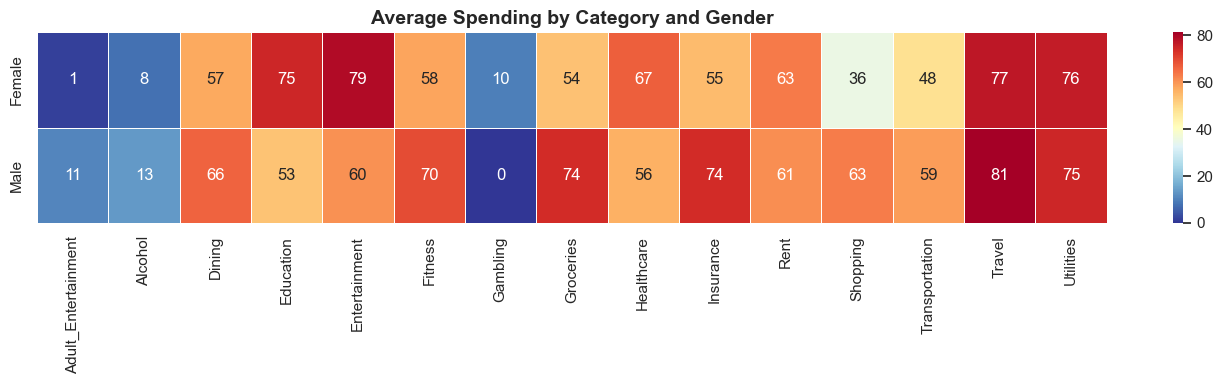

=== Largest Spending Differences by Gender ===
  Shopping: Female=36, Male=63 (diff=-28)
  Education: Female=75, Male=53 (diff=+21)
  Groceries: Female=54, Male=74 (diff=-20)
  Insurance: Female=55, Male=74 (diff=-19)
  Entertainment: Female=79, Male=60 (diff=+19)


In [28]:
# Compute average spending per category for each gender
spending_by_gender = df_bias.groupby('applicant_info.gender')[spending_cols].mean()

# Clean column names for nicer display in the heatmap
spending_by_gender.columns = [c.replace('spending_', '') for c in spending_cols]

# Heatmap of average spending patterns by gender
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    spending_by_gender, annot=True, fmt='.0f', cmap='RdYlBu_r', ax=ax,
    linewidths=0.5, linecolor='white'
)
ax.set_title('Average Spending by Category and Gender', fontsize=14, fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/spending_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify the categories with the largest average spending differences (Female - Male)
print('=== Largest Spending Differences by Gender ===')
diff = spending_by_gender.loc['Female'] - spending_by_gender.loc['Male']
diff_sorted = diff.abs().sort_values(ascending=False)

for cat in diff_sorted.head(5).index:
    f_val = spending_by_gender.loc['Female', cat]
    m_val = spending_by_gender.loc['Male', cat]
    print(f'  {cat}: Female={f_val:.0f}, Male={m_val:.0f} (diff={f_val-m_val:+.0f})')

=== Approval Rates by Income Bracket and Gender ===
                        mean         count     
applicant_info.gender Female   Male Female Male
income_bracket                                 
<50k                   0.242  0.424     33   33
50-75k                 0.478  0.618     69   68
75-100k                0.544  0.750     79   88
100k+                  0.623  0.707     69   58


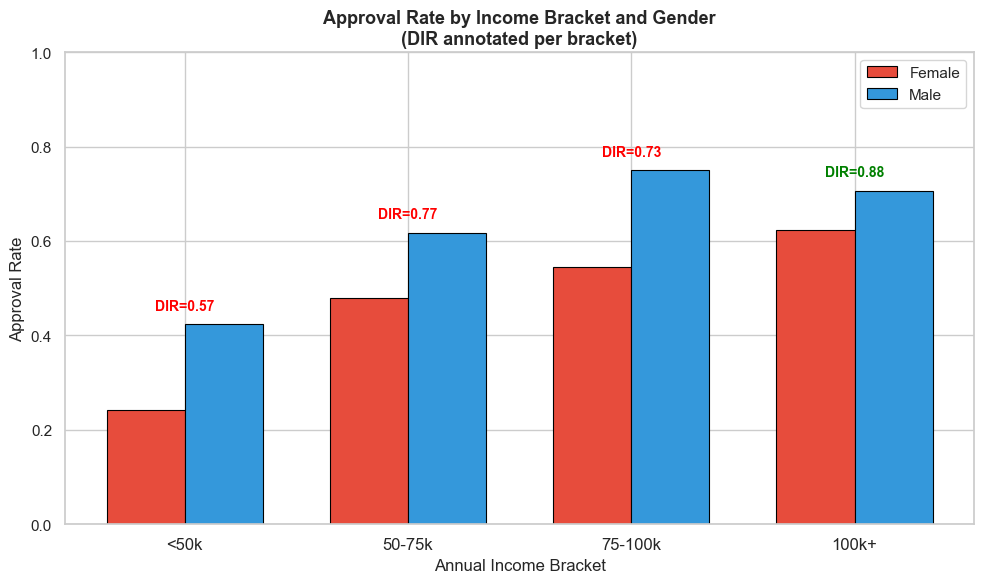


Female applicants have lower approval rates across ALL income brackets.
The disparity is NOT explained by income differences alone.


In [30]:
# 6.4 Approval rates within comparable income brackets (controlling for income)
# Create income brackets to compare applicants with similar income levels
df_bias['income_bracket'] = pd.cut(
    df_bias['financials.annual_income'],
    bins=[0, 50000, 75000, 100000, 200000],
    labels=['<50k', '50-75k', '75-100k', '100k+']
)

# Compute approval rate and sample size for each gender within each income bracket
bracket_rates = (
    df_bias.groupby(['income_bracket', 'applicant_info.gender'])['approved_binary']
    .agg(['mean', 'count'])
    .unstack()
)

print('=== Approval Rates by Income Bracket and Gender ===')
print(bracket_rates.round(3))

# --- Visualization of approval rates ---
fig, ax = plt.subplots(figsize=(10, 6))

brackets = ['<50k', '50-75k', '75-100k', '100k+']
female_rates = [bracket_rates.loc[b, ('mean', 'Female')] for b in brackets]
male_rates = [bracket_rates.loc[b, ('mean', 'Male')] for b in brackets]

x = np.arange(len(brackets))
width = 0.35

# Bar chart comparing approval rates within each income bracket
ax.bar(x - width/2, female_rates, width, label='Female',
       color='#e74c3c', edgecolor='black', linewidth=0.8)
ax.bar(x + width/2, male_rates, width, label='Male',
       color='#3498db', edgecolor='black', linewidth=0.8)

# Annotate Disparate Impact Ratio (DIR) for each bracket
for i, (fr, mr) in enumerate(zip(female_rates, male_rates)):
    di = fr / mr if mr > 0 else 0
    ax.annotate(
        f'DIR={di:.2f}', (i, max(fr, mr) + 0.03),
        ha='center', fontsize=10,
        color='red' if di < 0.8 else 'green',
        fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(brackets, fontsize=12)
ax.set_ylabel('Approval Rate', fontsize=12)
ax.set_xlabel('Annual Income Bracket', fontsize=12)
ax.set_title(
    'Approval Rate by Income Bracket and Gender\n(DIR annotated per bracket)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../reports/income_bracket_bias.png', dpi=150, bbox_inches='tight')
plt.show()

# Final interpretation printed for the notebook
print('\nFemale applicants have lower approval rates across ALL income brackets.')
print('The disparity is NOT explained by income differences alone.')

In [33]:
# 6.5 Financial profile comparison — are female applicants objectively riskier?
# Compare key financial indicators between female and male applicants
# The goal is to check whether women are objectively riskier borrowers

print('=== Financial Profile Comparison by Gender ===')
print('If the approval disparity is fair, female applicants should have worse financial profiles.\n')

for col in financial_cols:

    # Remove the prefix to make output cleaner
    col_short = col.replace('financials.', '')

    # Extract values for each gender
    f_vals = df_bias[df_bias['applicant_info.gender'] == 'Female'][col].dropna()
    m_vals = df_bias[df_bias['applicant_info.gender'] == 'Male'][col].dropna()

    # Compute mean values
    f_mean, m_mean = f_vals.mean(), m_vals.mean()

    # Percentage difference between female and male means
    diff_pct = ((f_mean - m_mean) / m_mean) * 100 if m_mean != 0 else 0

    # Two-sample t-test to check if the difference is statistically significant
    t_stat, t_pval = stats.ttest_ind(f_vals, m_vals)

    # Mark statistically significant differences
    sig = '*' if t_pval < 0.05 else ''

    # Print results
    print(f'{col_short}:')
    print(f'  Female mean: {f_mean:.2f} | Male mean: {m_mean:.2f} | Diff: {diff_pct:+.1f}% | p={t_pval:.4f} {sig}')

print('\n* = statistically significant difference at p < 0.05')

# print('\nConclusion: Financial profiles are largely comparable between genders,')
# print('yet approval rates differ significantly — supporting a finding of algorithmic bias.')

=== Financial Profile Comparison by Gender ===
If the approval disparity is fair, female applicants should have worse financial profiles.

annual_income:
  Female mean: 83770.65 | Male mean: 81295.55 | Diff: +3.0% | p=0.3264 
credit_history_months:
  Female mean: 51.43 | Male mean: 49.78 | Diff: +3.3% | p=0.5549 
debt_to_income:
  Female mean: 0.24 | Male mean: 0.25 | Diff: -1.8% | p=0.7166 
savings_balance:
  Female mean: 29552.26 | Male mean: 29659.85 | Diff: -0.4% | p=0.9428 

* = statistically significant difference at p < 0.05


A **comparison of key financial indicators shows no statistically significant differences between male and female applicants in income, credit history length, debt-to-income ratio, or savings balance.** Despite these comparable financial profiles, female applicants exhibit consistently lower approval rates, suggesting that the observed disparity cannot be explained by objective credit risk factors and may instead indicate bias in the decision-making process.

---
## 7. Summary Dashboard

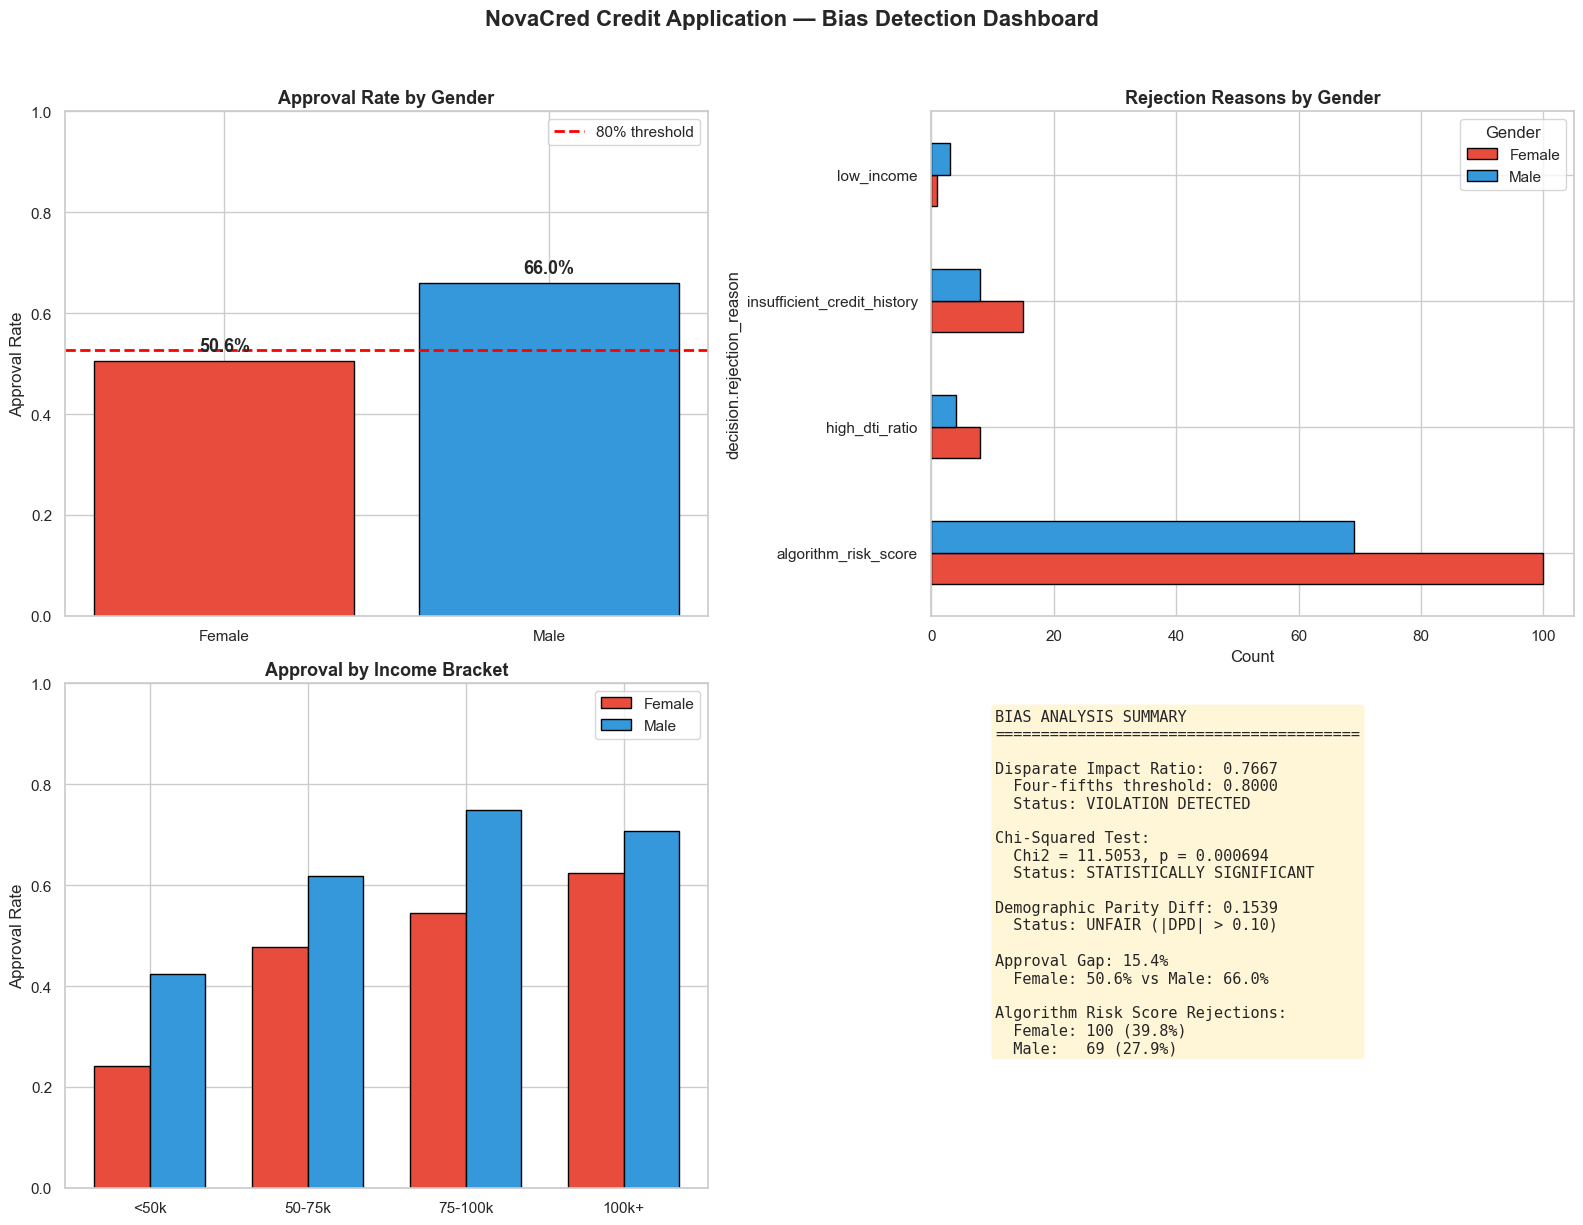

In [34]:
# Create a 2x2 “dashboard” figure summarizing the key bias findings
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Approval rates by gender (top-left)
ax = axes[0, 0]
bars = ax.bar(['Female', 'Male'], [rate_female, rate_male],
              color=['#e74c3c', '#3498db'], edgecolor='black')

# Draw the four-fifths (80%) threshold line relative to the male approval rate
ax.axhline(y=rate_male * 0.8, color='red', linestyle='--', linewidth=2, label='80% threshold')

ax.set_title('Approval Rate by Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('Approval Rate')
ax.set_ylim(0, 1)

# Annotate each bar with its approval rate
for bar, rate in zip(bars, [rate_female, rate_male]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{rate:.1%}', ha='center', fontsize=13, fontweight='bold')
ax.legend()

# 2) Rejection reasons by gender (top-right)
ax = axes[0, 1]

# Cross-tab: counts of each rejection reason, split by gender
rejection_counts_plot = pd.crosstab(rejected['decision.rejection_reason'],
                                    rejected['applicant_info.gender'])

# Horizontal bar chart for easier category readability
rejection_counts_plot.plot(kind='barh', ax=ax,
                           color=['#e74c3c', '#3498db'], edgecolor='black')

ax.set_title('Rejection Reasons by Gender', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
ax.legend(title='Gender')

# 3) Approval rates within income brackets (bottom-left)
ax = axes[1, 0]
x = np.arange(len(brackets))

ax.bar(x - 0.175, female_rates, 0.35, label='Female',
       color='#e74c3c', edgecolor='black')
ax.bar(x + 0.175, male_rates, 0.35, label='Male',
       color='#3498db', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(brackets)
ax.set_title('Approval by Income Bracket', fontsize=13, fontweight='bold')
ax.set_ylabel('Approval Rate')
ax.set_ylim(0, 1)
ax.legend()

# 4) Text-only box of key fairness metrics (bottom-right)
ax = axes[1, 1]
ax.axis('off')  # hide axes; we only want text

summary = (
    f'BIAS ANALYSIS SUMMARY\n'
    f'{"="*40}\n\n'
    f'Disparate Impact Ratio:  {DIR:.4f}\n'
    f'  Four-fifths threshold: 0.8000\n'
    f'  Status: VIOLATION DETECTED\n\n'
    f'Chi-Squared Test:\n'
    f'  Chi2 = {chi2:.4f}, p = {p_value:.6f}\n'
    f'  Status: STATISTICALLY SIGNIFICANT\n\n'
    f'Demographic Parity Diff: {dpd:.4f}\n'
    f'  Status: UNFAIR (|DPD| > 0.10)\n\n'
    f'Approval Gap: {rate_male - rate_female:.1%}\n'
    f'  Female: {rate_female:.1%} vs Male: {rate_male:.1%}\n\n'
    f'Algorithm Risk Score Rejections:\n'
    f'  Female: {algo_f} ({algo_f/total_f:.1%})\n'
    f'  Male:   {algo_m} ({algo_m/total_m:.1%})'
)

# Place the summary text on the panel with a highlighted box
ax.text(0.1, 0.95, summary, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#fff3cd', alpha=0.8))

# Figure-level title and export
plt.suptitle('NovaCred Credit Application — Bias Detection Dashboard',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../reports/bias_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Conclusions & Recommendations

### Key Findings

| Metric | Value | Threshold | Status |
|--------|-------|-----------|--------|
| Disparate Impact Ratio | 0.7667 | 0.80 | **VIOLATION** |
| Chi-Squared p-value | 0.0007 | 0.05 | **SIGNIFICANT** |
| Demographic Parity Diff | -0.154 | ±0.10 | **UNFAIR** |
| Approval Gap | 15.4% | — | Female disadvantaged |

### Detailed Findings

1. **Disparate Impact Confirmed:** Female applicants are approved at 50.6% vs. 66.0% for males. The DIR of 0.767 falls below the four-fifths rule threshold of 0.80, constituting evidence of adverse impact under EEOC guidelines.

2. **Statistically Significant:** The chi-squared test confirms the gender-approval association is statistically significant (p = 0.0007), meaning the disparity is not explained by random variation.

3. **Algorithm Risk Score is the Primary Driver:** The "algorithm_risk_score" rejection reason disproportionately affects female applicants (100 vs. 69 males), suggesting the scoring algorithm itself encodes gender bias.

4. **Bias Persists Across Income Levels:** Female approval rates are lower in every income bracket, demonstrating that the disparity is not explained by differences in income.

5. **Comparable Financial Profiles:** Male and female applicants have statistically similar income, credit history, and savings profiles, further undermining any business justification for the approval gap.

6. **Proxy Discrimination Risk:** Spending patterns (Shopping, Insurance, Groceries) differ by gender and correlate with approval outcomes, potentially serving as indirect gender proxies in the algorithm.

### Recommendations

1. **Audit the Risk Scoring Algorithm:** The `algorithm_risk_score` must be reviewed for features that directly or indirectly encode gender. Spending categories should be evaluated as potential proxy variables.

2. **Implement Fairness Constraints:** Apply demographic parity or equalized odds constraints during model training using tools like Fairlearn's `ThresholdOptimizer` or `ExponentiatedGradient`.

3. **Remove or Transform Proxy Features:** Spending categories that are strongly gender-correlated (Shopping, Groceries, Insurance) should be removed or de-biased before use in credit decisions.

4. **Establish Ongoing Monitoring:** Deploy automated fairness dashboards that compute DIR, DPD, and chi-squared statistics on a rolling basis, with alerts when metrics breach thresholds.

5. **Regulatory Compliance:** Under the **EU AI Act**, credit scoring is classified as a **high-risk AI system** (Annex III). NovaCred must ensure:
   - Bias testing before deployment (Art. 10)
   - Human oversight mechanisms (Art. 14)
   - Transparency and explainability of decisions (Art. 13)
   - Regular post-market monitoring (Art. 61)